In [7]:

# Handwriting Classifier
# Transfer Learning: MNIST CNN, Handwritten A-E Classifier



#!pip install tensorflow opencv-python matplotlib scikit-learn

import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2

from IPython.display import display
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# set a seed for reproducibility
SEED = 23
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [8]:

# 1. Attaching handwritten letters


# Local paths
#local_paths = [
#    "/mnt/data/IMG_0154.jpg",  # A
 #   "/mnt/data/IMG_0155.jpg",  # B
  #  "/mnt/data/IMG_0156.jpg",  # C
   # "/mnt/data/IMG_0157.jpg",  # D
    #"/mnt/data/IMG_0158.jpg",  # E
#]

# Google paths if attaching directly to colab's files in left side bar
drive_paths = [
    "/content/IMG_0154.jpg",  # A
    "/content/IMG_0155.jpg",  # B
    "/content/IMG_0156.jpg",  # C
    "/content/IMG_0157.jpg",  # D
    "/content/IMG_0158.jpg",  # E
]

# Use local paths if available, otherwise use Drive paths
#if all(os.path.exists(p) for p in local_paths):
 #   image_paths = local_paths
#else:
    # If using Colab, uncomment these lines to access google drive to get images:
    #from google.colab import drive
    #drive.mount("/content/drive")
image_paths = drive_paths

letters = np.array(["A", "B", "C", "D", "E"])
letter_labels = np.arange(len(letters))

missing_files = [p for p in image_paths if not os.path.exists(p)]
if missing_files:
    raise FileNotFoundError(f"Missing image files: {missing_files}")

print("Letter files:")
for letter, path in zip(letters, image_paths):
    print(letter, "->", path)

Letter files:
A -> /content/IMG_0154.jpg
B -> /content/IMG_0155.jpg
C -> /content/IMG_0156.jpg
D -> /content/IMG_0157.jpg
E -> /content/IMG_0158.jpg


letter_images shape: (5, 28, 28, 1)


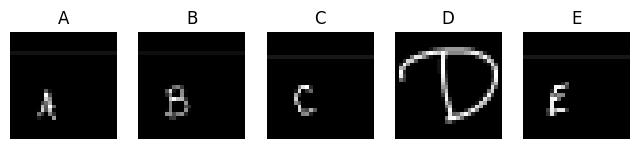

In [9]:

# 2. Preprocess attached images


def preprocess_letter_image(path, target_size=28, margin=8, debug=False):
    """
    Converts handwritten letter image into MNIST like input.

    Output:
    - 28x28 grayscale image
    - black background
    - white handwritten stroke
    - normalized to [0, 1]
    - shape: (28, 28, 1)
    """

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {path}")

    # Blur removes small image noise; Gaussian Blur - this has led to higher accuracy
    #blurred = cv2.GaussianBlur(img, (5, 5), 0)

    #or use median blur since it is best used for handwritting
    blurred = cv2.medianBlur(img, 3)

    # Inverted threshold: dark handwriting becomes white foreground
    _, mask = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Find ink pixels
    coords = cv2.findNonZero(mask)

    if coords is None:
        raise ValueError(f"No handwriting detected in image: {path}")

    # Bounding box around handwriting
    x, y, w, h = cv2.boundingRect(coords)

    # Add margin around  handwriting
    x0 = max(x - margin, 0)
    y0 = max(y - margin, 0)
    x1 = min(x + w + margin, mask.shape[1])
    y1 = min(y + h + margin, mask.shape[0])

    crop = mask[y0:y1, x0:x1]

    # Pad to square that way the letters do not get distorted
    side = max(crop.shape[0], crop.shape[1])
    square = np.zeros((side, side), dtype=np.uint8)

    y_offset = (side - crop.shape[0]) // 2
    x_offset = (side - crop.shape[1]) // 2

    square[
        y_offset:y_offset + crop.shape[0],
        x_offset:x_offset + crop.shape[1]
    ] = crop

    # Resize to MNIST dimensions
    resized = cv2.resize(
        square,
        (target_size, target_size),
        interpolation=cv2.INTER_AREA
    )

    # Normalizing
    normalized = resized.astype("float32") / 255.0

    if debug:
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))

        axes[0].imshow(img, cmap="gray")
        axes[0].set_title("Original")
        axes[1].imshow(mask, cmap="gray")
        axes[1].set_title("Thresholded Ink")
        axes[2].imshow(crop, cmap="gray")
        axes[2].set_title("Cropped")
        axes[3].imshow(normalized, cmap="gray")
        axes[3].set_title("Final 28x28")

        for ax in axes:
            ax.axis("off")

        plt.show()

    return normalized[..., np.newaxis]


# Process all A-E images
letter_images = np.stack([
    preprocess_letter_image(path, debug=False)
    for path in image_paths
])

print("letter_images shape:", letter_images.shape)

# Preview processed letters
plt.figure(figsize=(8, 2))

for i, img in enumerate(letter_images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(letters[i])
    plt.axis("off")

plt.show()

In [10]:

# 3. Train base CNN on MNIST digits


(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and add channel dimension
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

base_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", name="conv_1"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", name="conv_2"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", name="conv_3"),

    layers.Flatten(name="flatten"),
    layers.Dense(128, activation="relu", name="feature_dense"),
    layers.Dropout(0.25),

    layers.Dense(10, activation="softmax", name="digit_output")
])

base_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

base_model.summary()

base_history = base_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=2,
            restore_best_weights=True
        )
    ]
)

base_loss, base_acc = base_model.evaluate(x_test, y_test, verbose=0)
print(f"MNIST test accuracy: {base_acc:.4f}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dense (Dense)           │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit_output (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 111ms/step - accuracy: 0.9208 - loss: 0.2592 - val_accuracy: 0.9841 - val_loss: 0.0474
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.9808 - loss: 0.0625 - val_accuracy: 0.9881 - val_loss: 0.0349
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - accuracy: 0.9870 - loss: 0.0428 - val_accuracy: 0.9872 - val_loss: 0.0353
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 110ms/step - accuracy: 0.9894 - loss: 0.0342 - val_accuracy: 0.9895 - val_loss: 0.0320
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - accuracy: 0.9914 - loss: 0.0275 - val_accuracy: 0.9917 - val_loss: 0.0246
MNIST test accuracy: 0.9917


In [11]:

# 4. Build augmented A-E dataset


augmenter = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.15,
    shear_range=8,
    fill_mode="constant",
    cval=0.0
)

def make_augmented_dataset(images, labels, copies_per_image=250):
    """
    Since there is only one real image per letter,
    create many augmented versions of each image.
    """

    X_aug, y_aug = [], []

    for img, label in zip(images, labels):
        img_batch = img[np.newaxis, ...]

        gen = augmenter.flow(
            img_batch,
            batch_size=1,
            shuffle=False,
            seed=SEED + int(label)
        )

        # Add original image
        X_aug.append(img)
        y_aug.append(label)

        # Add augmented copies
        for _ in range(copies_per_image):
            aug_img = next(gen)[0]
            X_aug.append(aug_img)
            y_aug.append(label)

    return np.asarray(X_aug, dtype="float32"), np.asarray(y_aug, dtype="int64")

# Actually create X_letters and y_letters before splitting.
X_letters, y_letters = make_augmented_dataset(
    letter_images,
    letter_labels,
    copies_per_image=250
)

print("Full augmented dataset shape:", X_letters.shape)
print("Full label shape:", y_letters.shape)

# First split: separate out the test set
X_temp_letters, X_test_letters, y_temp_letters, y_test_letters = train_test_split(
    X_letters,
    y_letters,
    test_size=0.20,
    random_state=SEED,
    stratify=y_letters
)

# Second split: split remaining data into training and validation
X_train_letters, X_val_letters, y_train_letters, y_val_letters = train_test_split(
    X_temp_letters,
    y_temp_letters,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp_letters
)

print("Training shape:", X_train_letters.shape)
print("Validation shape:", X_val_letters.shape)
print("Testing shape:", X_test_letters.shape)


Full augmented dataset shape: (1255, 28, 28, 1)
Full label shape: (1255,)
Training shape: (753, 28, 28, 1)
Validation shape: (251, 28, 28, 1)
Testing shape: (251, 28, 28, 1)


Now we can see each individual accuracy per letter instead

In [12]:

# Accuracy  for A, B, C, D, E
# Class-wise validation and testing accuracy

class ClassWiseAccuracyCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, test_data, class_names):
        super().__init__()

        self.X_val, self.y_val = val_data
        self.X_test, self.y_test = test_data
        self.class_names = class_names

        self.class_history = {
            "val": {letter: [] for letter in class_names},
            "test": {letter: [] for letter in class_names}
        }

    def on_epoch_end(self, epoch, logs=None):
        val_preds = np.argmax(
            self.model.predict(self.X_val, verbose=0),
            axis=1
        )

        test_preds = np.argmax(
            self.model.predict(self.X_test, verbose=0),
            axis=1
        )

        for class_id, letter in enumerate(self.class_names):
            val_mask = self.y_val == class_id
            test_mask = self.y_test == class_id

            val_acc = np.mean(val_preds[val_mask] == self.y_val[val_mask])
            test_acc = np.mean(test_preds[test_mask] == self.y_test[test_mask])

            self.class_history["val"][letter].append(val_acc)
            self.class_history["test"][letter].append(test_acc)

        print("\nClass-wise test accuracy:")
        for letter in self.class_names:
            latest_test_acc = self.class_history["test"][letter][-1]
            print(f"{letter}: {latest_test_acc:.3f}", end=" | ")
        print()

In [13]:

# 5. Transfer learning: MNIST features, A-E classifier


_ = base_model(tf.zeros((1, 28, 28, 1)))

feature_extractor = tf.keras.Model(
    inputs=base_model.inputs,
    outputs=base_model.get_layer("feature_dense").output,
    name="mnist_feature_extractor"
)

feature_extractor.trainable = False

transfer_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    feature_extractor,
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(5, activation="softmax", name="letter_output")
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

head_class_callback = ClassWiseAccuracyCallback(
    val_data=(X_val_letters, y_val_letters),
    test_data=(X_test_letters, y_test_letters),
    class_names=letters
)

head_history = transfer_model.fit(
    X_train_letters,
    y_train_letters,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_letters, y_val_letters),
    callbacks=[
        head_class_callback,
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1 #shows progress bar
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mnist_feature_extractor         │ (None, 128)            │       129,600 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ letter_output (Dense)           │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,181 (539.77 KB)

 Trainable params: 8,581 (33.52 KB)

 Non-trainable params: 129,600 (506.25 KB)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2316 - loss: 1.5286 
Class-wise test accuracy:
A: 0.000 | B: 0.800 | C: 0.740 | D: 1.000 | E: 0.080 | 
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.2590 - loss: 1.4543 - val_accuracy: 0.5219 - val_loss: 1.2600
Epoch 2/30
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4395 - loss: 1.2844
Class-wise test accuracy:
A: 0.000 | B: 0.840 | C: 0.940 | D: 1.000 | E: 0.180 | 
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4967 - loss: 1.2349 - val_accuracy: 0.6135 - val_loss: 1.1088
Epoch 3/30
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5785 - loss: 1.1318
Class-wise test accuracy:
A: 0.300 | B: 0.860 | C: 1.000 | D: 1.000 | E: 0.020 | 
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5551 - loss: 1.1110 - val_accuracy: 0.6454 - val_loss: 0.9948
Epoch 4/30
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5829 - loss: 1.0429
Class-wise test accuracy:
A: 0.440 | B: 0.840 | C: 1.000 | D: 1.000 

In [14]:

# 6. Finetuning


feature_extractor.trainable = True
for layer in feature_extractor.layers[:4]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_class_callback = ClassWiseAccuracyCallback(
    val_data=(X_val_letters, y_val_letters),
    test_data=(X_test_letters, y_test_letters),
    class_names=letters
)

fine_history = transfer_model.fit(
    X_train_letters,
    y_train_letters,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_letters, y_val_letters),
    callbacks=[
        fine_class_callback,
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

val_loss, val_acc = transfer_model.evaluate(
    X_val_letters,
    y_val_letters,
    verbose=0
)

# verbose = 0 is for a silent run

print(f"A-E validation accuracy on augmented images: {val_acc:.4f}")

Epoch 1/20
21/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8356 - loss: 0.4150
Class-wise test accuracy:
A: 0.900 | B: 0.960 | C: 0.980 | D: 1.000 | E: 0.940 | 
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8420 - loss: 0.4136 - val_accuracy: 0.9641 - val_loss: 0.2721
Epoch 2/20
21/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8473 - loss: 0.4081
Class-wise test accuracy:
A: 0.900 | B: 0.960 | C: 0.960 | D: 1.000 | E: 0.940 | 
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8579 - loss: 0.3978 - val_accuracy: 0.9602 - val_loss: 0.2668
Epoch 3/20
21/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8556 - loss: 0.3780
Class-wise test accuracy:
A: 0.900 | B: 0.960 | C: 0.980 | D: 1.000 | E: 0.940 | 
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8632 - loss: 0.3789 - val_accuracy: 0.9602 - val_loss: 0.2611
Epoch 4/20
21/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8648 - loss: 0.3842
Class-wise test accuracy:
A: 0.900 | B: 0.960 | C: 0.980 | D: 1.00

In [15]:

# 7. Final prediction and evaluation on original A-E images


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd

# Predict probabilities for the original letter images
probs = transfer_model.predict(letter_images, verbose=0)

# Convert probabilities into predicted class IDs
pred_ids = np.argmax(probs, axis=1)

# Pred IDs into actual letters
pred_letters = letters[pred_ids]

# True labels for original files: A=0, B=1, C=2, D=3, E=4
true_ids = letter_labels
true_letters = letters

# Confidence score for each pred
confidences = np.max(probs, axis=1)

# Create results table
results_df = pd.DataFrame({
    "File": [os.path.basename(path) for path in image_paths],
    "Expected Letter": true_letters,
    "Predicted Letter": pred_letters,
    "Confidence": np.round(confidences, 4),
    "Correct?": true_letters == pred_letters
})

display(results_df)



,File,Expected Letter,Predicted Letter,Confidence,Correct?
0,IMG_0154.jpg,A,A,0.9186,True
1,IMG_0155.jpg,B,B,0.9999,True
2,IMG_0156.jpg,C,C,0.6531,True
3,IMG_0157.jpg,D,D,1.0000,True
4,IMG_0158.jpg,E,E,0.8571,True


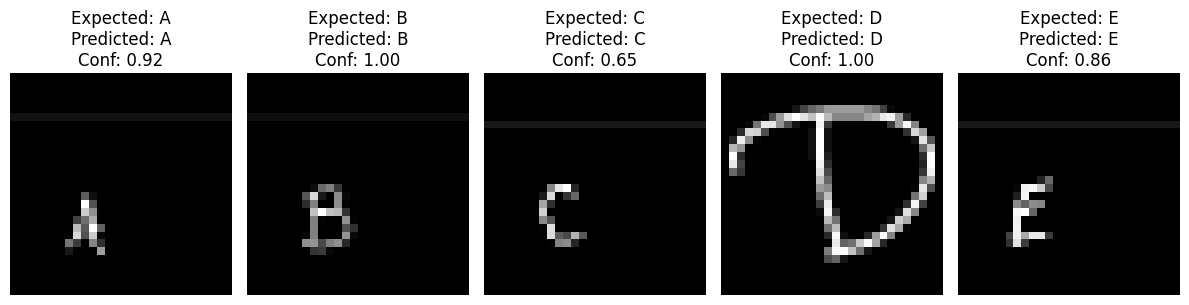

In [16]:

# 7A. Original processed images with predictions


plt.figure(figsize=(12, 3))

for i, img in enumerate(letter_images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")

    title = (
        f"Expected: {true_letters[i]}\n"
        f"Predicted: {pred_letters[i]}\n"
        f"Conf: {confidences[i]:.2f}"
    )

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

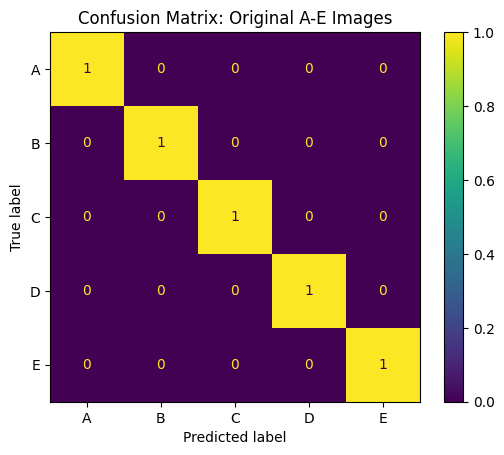

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         1
           B       1.00      1.00      1.00         1
           C       1.00      1.00      1.00         1
           D       1.00      1.00      1.00         1
           E       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [17]:

# 7B. Confusion matrix for A-E predictions


cm = confusion_matrix(
    true_ids,
    pred_ids,
    labels=np.arange(len(letters))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=letters
)

disp.plot()
plt.title("Confusion Matrix: Original A-E Images")
plt.show()

print("Classification Report:")
print(
    classification_report(
        true_ids,
        pred_ids,
        labels=np.arange(len(letters)),
        target_names=letters,
        zero_division=0
    )
)

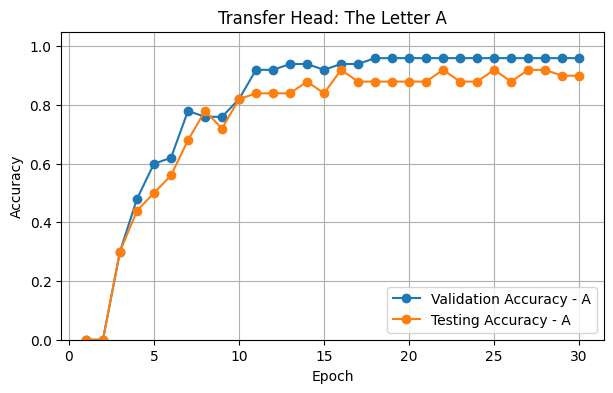

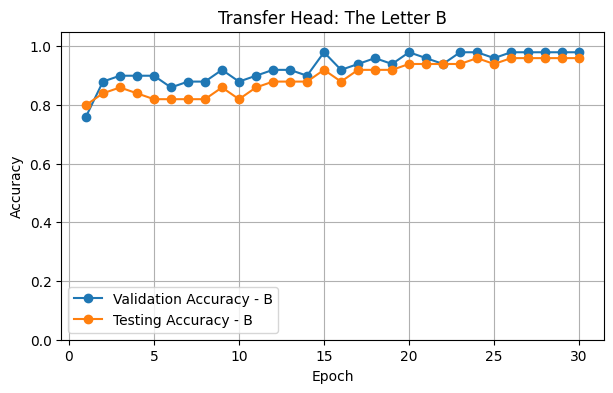

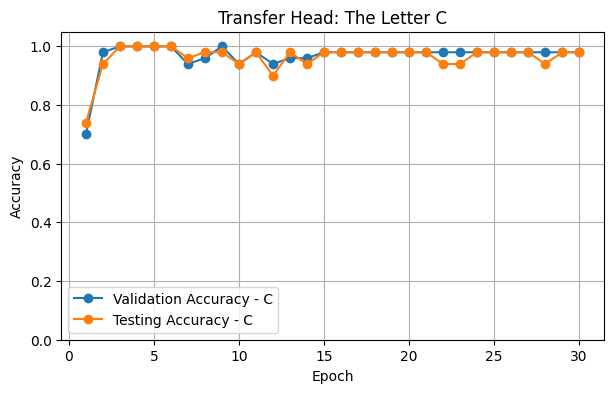

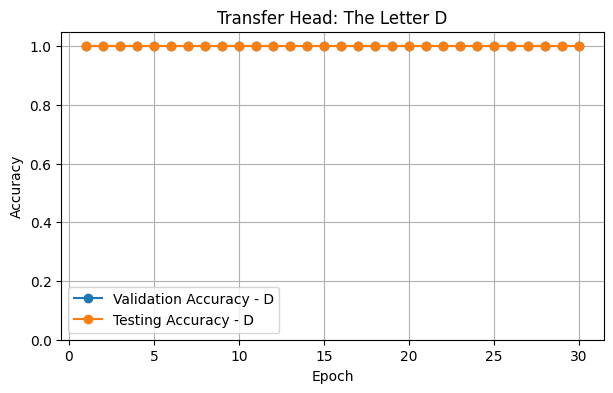

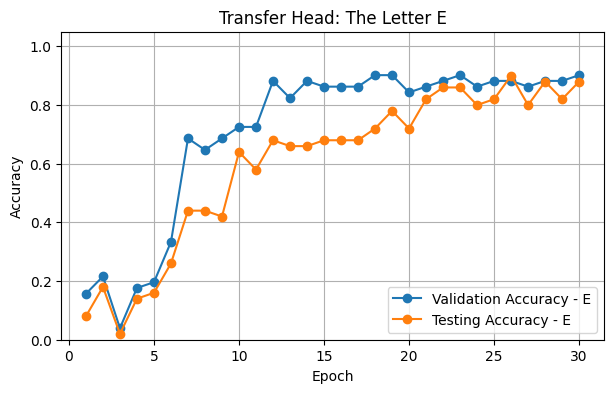

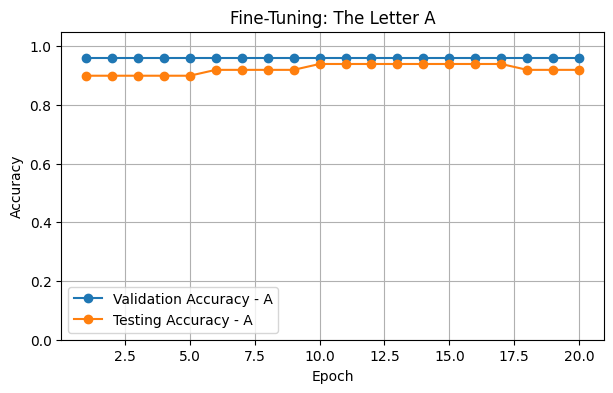

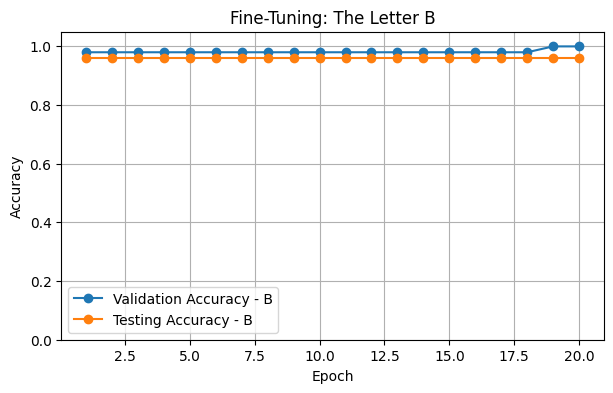

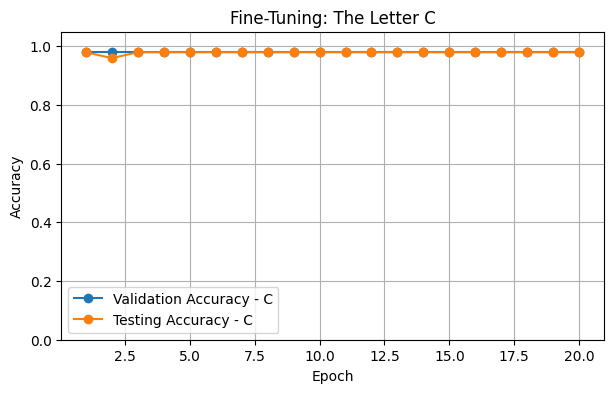

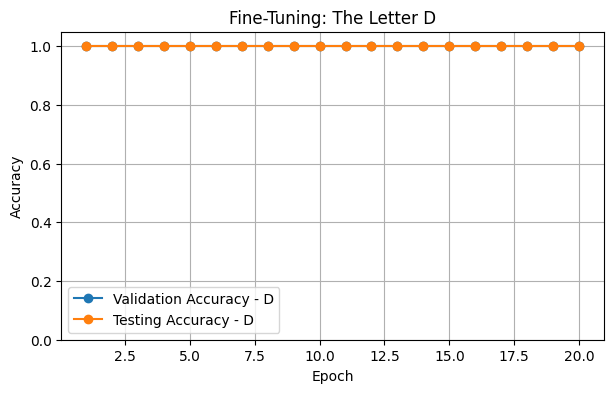

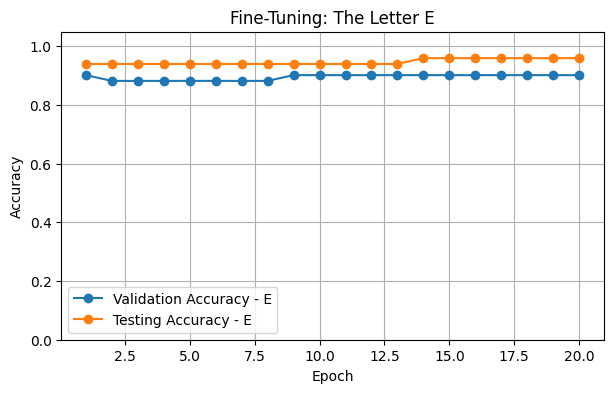

In [18]:

# 8. Separate validation/testing curves for each letter


def plot_letter_curves(class_callback, title_prefix):
    """
    Creates one separate plot for each letter with validation accuracy
    and testing accuracy for each letter.
    """

    for letter in class_callback.class_names:
        val_acc = class_callback.class_history["val"][letter]
        test_acc = class_callback.class_history["test"][letter]

        epochs = range(1, len(test_acc) + 1)

        plt.figure(figsize=(7, 4))

        plt.plot(
            epochs,
            val_acc,
            marker="o",
            label=f"Validation Accuracy - {letter}"
        )

        plt.plot(
            epochs,
            test_acc,
            marker="o",
            label=f"Testing Accuracy - {letter}"
        )

        plt.title(f"{title_prefix}: The Letter {letter}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1.05)
        plt.legend()
        plt.grid(True)
        plt.show()


plot_letter_curves(
    head_class_callback,
    "Transfer Head"
)

plot_letter_curves(
    fine_class_callback,
    "Fine-Tuning"
)